# Questão 1

### 1. a)

Queremos uma reflexão que leve $x$ até $||x||e_1$. Ou seja, queremos que $v$ seja o vetor normal ao hiperplano que reflete $x$ em $||x||e_1$. Para $v$ ser o vetor normal a esse hiperplano, ele deve ser a normal a mediatriz entre os vetores $x$ e $||x||e_1$, então $v = x - ||x||e_1$.

Encontrando $\beta$: $$Q_{v}x = x - \beta vv^{*}x = ||x||e_1$$
$$\beta vv^{*}x = x - ||x||e_1 = v$$
$$\beta = \frac{1}{v^{*}x}$$

Abrindo $v^{*}$ temos: $v^{*} = (x - ||x||e_1)^{*} = x^* - ||x||e_{1}^*$

Substituindo: $$\beta = \frac{1}{(x^* - ||x||e_{1}^*)x} = \frac{1}{x^{*}x - ||x||e_{1}^{*}x} = \frac{1}{||x||^2 - ||x||x_1} = \frac{1}{||x||(||x|| - x_1)} = \frac{1}{||x||(||x|| - x_1)} \cdot \frac{||x|| + x_1}{||x|| + x_1} = \frac{||x|| + x_1}{||x||(||x||^2 - x_{1}^2)}$$

Observe que $||x||^2 = x_{1}^2 + x_{2}^2 + \cdots + x_{n}^2$ 

Então $||x||^2 - x_{1}^2 = x_{2}^2 + x_{3}^2 + \cdots + x_{n}^2 = ||y||^2$, já que $y = (x_2, ..., x_n)$

Logo, $$ \frac{||x|| + x_1}{||x||(||x||^2 - x_{1}^2)} = \frac{||x|| + x_1}{||x||\cdot ||y||^2}$$

Observação: note que estamos usando a norma $2$ (euclidiana).

### 1. b)

Temos duas fórmulas equivalentes para $\beta$: $$\beta _{1} = \frac{1}{||x||(||x|| - x_1)} \hspace{4cm} \beta _{2} = \frac{||x|| + x_1}{||x|| \cdot ||y||^2}$$ 
Quando $x_1 > 0$: 

Se $x_1 > 0$ e próximo de $||x||$ temos: $$||x|| - x_1 \approx 0$$
Na fórmula $\beta _{1}$ o denominador envolve diretamente essa subtração, o que pode causar um erro muito grande ao realizar a subtração entre dois float64, perdendo a precisão da resposta. Já $\beta _{2}$ não tem esse problema pois o numerador é a soma de dois positivos e o denominador também não sofre cancelamento.

Quando $x_1 < 0$: 

Se $x_1 < 0$ e próximo de $-||x||$ temos: $$||x|| + x_1 \approx 0$$
Na fórmula $\beta _{2}$ o numerador sofre cancelamento, perdendo a precisão da resposta. Já $\beta _{1}$ não tem esse problema o denominador se transformará em uma soma de números positivos. 

**Mas a pergunta é: por que ao realizar a subtração de dois números muito próximos usando ponto flutuante pode gerar um erro enorme?**

A resposta está em como números de ponto flutuante são armazenados. Ele é dividido em $1$ bit para o sinal, $11$ bits para o campo do expoente e $52$ bits para a mantissa, o que confere uma precisão relativa da ordem de $\epsilon _{maq} \approx 2^{-52} \approx 2.2 \times 10^{-16}$ Isso significa que cada número carrega um erro absoluto da ordem de $\epsilon _{maq} \cdot |x|$. Quando subtraimos dois números muito próximos, os algarismos significativos se cancelam e o que resta no resultado são os bits menos significativos, os mais contaminados por erros de arredondamento (ao armazenar um número em ponto flutuante, o arredondamento para o representável mais próximo afeta a posição menos significativa da mantissa, pois os bits mais significativos já capturam a maior parte do valor com exatidão, e o resíduo que não cabe na representação é arredondado no último bit. Assim, quando a subtração cancela os bits mais significativos, o que sobra no resultado são exatamente os bits que carregavam esse erro de arredondamento). O erro relativo do resultado é da ordem de $\frac{\epsilon _{maq} \cdot ||x||}{||x|| - x_1}$, que explode quando $||x|| - x_1 \rightarrow 0$. 

Portanto, dependendo do sinal de $x_1$, umas das fórmulas sempre é melhor de se usar do que a outra por não envolver cancelamento numérico.


### 1. c)

In [2]:
import numpy as np

def reflector(x):
    m = int(x.shape[0])
    e1 = np.zeros(m, dtype=x.dtype)
    e1[0] = 1 # vetor canonico com 1 na posição 1

    v = x - np.linalg.norm(x).astype(x.dtype) * e1
    y = x[1:]

    if(x[0] > 0): # para diminuir a perda de precisão
        beta = (np.linalg.norm(x) + x[0]) / (np.linalg.norm(x) * (np.linalg.norm(y)**2))
    else:
        beta = 1 / (np.linalg.norm(x) * (np.linalg.norm(x) - x[0]))

    Q = np.eye(m, m) - beta * (v @ v.T)

    return v, beta

x0 = np.array([2, 2], dtype=float)
v0, beta0 = reflector(x0)
print(v0, beta0)


[-0.82842712  2.        ] 0.4267766952966368


### 1. d)

$$v = x - ||x||e_1$$
$$\frac{\partial v}{\partial x} = \frac{\partial x}{\partial x} - e_1\frac{\partial ||x||}{\partial x}$$
$$\frac{\partial v}{\partial x} = I - e_1\frac{\partial ||x||}{\partial x}$$
Utilizando a regra da cadeia $\frac{d}{du}\sqrt{u} = \frac{1}{2\sqrt{u}}u'$:
$$= \frac{1}{2\sqrt{x_{1}^2 + x_{2}^2 + \cdots + x_{n}^2}} \cdot 2x_j = \frac{x_j}{||x||}$$
Juntando todas as componentes:$$\nabla x = \begin{bmatrix}
\frac{x_1}{||x||} \\
\vdots \\
\frac{x_n}{||x||} 
\end{bmatrix} = \frac{x}{||x||}$$
Então, concluimos que: $$J = I - e_1 \frac{x^T}{||x||} = I - \frac{e_1 \cdot x^*}{||x||}$$
Para calcular o número de condicionamento absoluto de de $v$ em relação a $x$ precisamos calcular: $$\kappa _{abs} = ||J||_2 = ||I - \frac{e_1 x^*}{||x||}||_2$$ e como sabemos, a norma 2 de uma matriz é o seu maior valor singular.

Sem perda de generalidade podemos assumirr $||x|| = 1$ (se não for é só normalizar). Então $J = I - e_{1}x^*$.

**O que J faz com qualquer vetor $u$?**

$$Ju = u - e_1(x^{*}u)$$
Note que $x^*u$ é um escalar. Chamando ele de $\alpha$: $$Ju = u - e_1\alpha$$
Ou seja, $J$ só altera a primeira posição do vetor $u$, subtraindo $\alpha$.

Pela desigualdade triangular temos: $$||Ju|| = ||u - \alpha e_1|| \leq ||u|| + |\alpha| ||e_1||$$
Como $|\alpha| = |x^*u| \leq ||x||\cdot||u|| = ||u||$ e $||e_1|| = 1$: $$||Ju|| \leq ||u|| + ||u|| = 2||u||$$ 
Como a definição formal da norma $2$ de uma matriz é: $$||J||_2 = \underset{||u||=1}{max}||Ju||_2$$
Portanto: $$ ||J||_2 = \underset{||u||=1}{max}||Ju|| \leq 2||u|| = 2$$
$$\kappa _{abs} \leq 2$$

**Quando a igualdade é atingida?**

Quando $u = e_1$ e $x = -e_1$:
$$Ju = e_1 - (-1)e_1 = 2e_1 \implies ||Ju|| = 2$$

### 1. e)


In [3]:
print("===================== E X E M P L O  2 x 1 ========================")

x = np.array([2, 2], dtype=np.float32)
v1, beta1 = reflector(x)
print("--------------FLOAT32---------------")
print(f"v: type {v1.dtype}, valor: {v1}")
print(f"beta: type {beta1.dtype}, valor: {beta1}")

y = np.array([2, 2], dtype=np.float64)
v2, beta2 = reflector(y)
print("--------------FLOAT64---------------")
print(f"v: type {v2.dtype}, valor: {v2}")
print(f"beta: type {beta2.dtype}, valor: {beta2}")

print("===================== E X E M P L O  500 x 1 ========================")

y1 = (np.random.rand(500)).astype(np.float64)

x1 = y1.astype(np.float32)
v3, beta3 = reflector(x1)
print("--------------FLOAT32---------------")
print(f"v: type {v3.dtype}")
print(f"beta: type {beta3.dtype}, valor: {beta3}")

v4, beta4 = reflector(y1)
print("--------------FLOAT64---------------")
print(f"v: type {v4.dtype}")
print(f"beta: type {beta4.dtype}, valor: {beta4}")

===================== E X E M P L O  2 x 1 ========================
--------------FLOAT32---------------
v: type float32, valor: [-0.8284271  2.       ]
beta: type float32, valor: 0.4267767071723938
--------------FLOAT64---------------
v: type float64, valor: [-0.82842712  2.        ]
beta: type float64, valor: 0.4267766952966368
===================== E X E M P L O  500 x 1 ========================
--------------FLOAT32---------------
v: type float32
beta: type float32, valor: 0.006094278302043676
--------------FLOAT64---------------
v: type float64
beta: type float64, valor: 0.006094276971440181


Primeiramente podemos ver que em ambos os casos de teste quando eu passo um vetor $Float32$, eu recebo um vetor $Float32$ de resposta, e a mesma coisa vale para um vetor $Float64$.

Note que em ambos os casos, tanto no vetor $2\times1$ quanto no vetor $500\times1$, os valores de $\beta$ começam a se diferenciar praticamente na mesma casa decimal para diferentes $Float$ ($10^{-8}$ para o vetor $\in \mathbb{R}^2$ e $10^{-9}$ para o vetor $\in \mathbb{R}^{500}$). Isso nos indica que o erro não explodirá quando o tamanho do problema crescer (pelo menos de 2 para 500 elementos). Isso também mostra que o algoritmo é estável, mesmo aumentando a dimensão do vetor para 500 elementos (o que envolve acumular centenas de somas e quadrados no cálculo da norma), a diferença entre o $Float32$ e o $Float64$ permaneceu controlada.



### 1. f)

Temos $v = (v_1, v_2, \dots, v_n)$ com $v_1 = x_1 - ||x||$ e com $v_i = x_i$ para $i = 2, \dots, n$. Isso porque quando fazemos $v = x - ||x||e_1$, note que o vetor $v$ difere apenas a primeira posição em relação ao vetor $x$. 

Agora, precisamos expressar $||x||$ e $x_1$ em função de $v$. Perceba que $||y||^2 = x_{2}^2 + \dots + x_{n}^2 = v_{2}^2 + \dots + v_{n}^2 = ||v||^2 - v_{1}^2$.

Sabemos que $||x|| = x_1 - v_1$ e que $||x||^2 = x_{1}^2 + ||y|||^2$, substituindo: $$(x_1 - v_1)^2 = x_{1}^2 + ||y||^2$$
$$x_{1}^2 - 2x_{1}v_{1} + v_{1}^2 = x_{1}^2 + ||y||^2$$
$$x_{1} = \frac{v_{1}^2 - ||y||^2}{2v_1}$$

Como $||x|| = x_1 - v_1$, então: $$||x|| = \frac{v_{1}^2 - ||y||^2}{2v_1} - \frac{2v_{1}^2}{2v_{1}} = \frac{-v_{1}^2 - ||y||^2}{2v_1} = - \frac{||v||^2}{2v_1}$$

Substituindo na fórmula $\beta _{2} = \frac{||x|| + x_1}{||x|| \cdot ||y||^2}$, temos: $$||x|| + x_1 = -\frac{||v||^2}{2v_1} + \frac{v_{1}^2 - ||y||^2}{2v_1} = \frac{-2||y||^2}{2v_1} = \frac{-||y||^2}{v_1}$$

Portanto, $$\beta = \frac{||x|| + x_1}{||x|| \cdot ||y||^2} = \frac{\frac{-||y||^2}{v_1}}{-\frac{||v||^2}{2v_1}(||y||^2)} = \frac{2}{||v||^2}$$

In [4]:
def calc_beta(v):
    return 2 / (np.linalg.norm(v))**2

v = np.array([2*(1 - 2**(1/2)),2], dtype=float)
print(calc_beta(v))

0.42677669529663687


Note que o $\beta$ é praticamente o mesmo da última questão, com a diferença sendo na casa de $10^{-8}$.

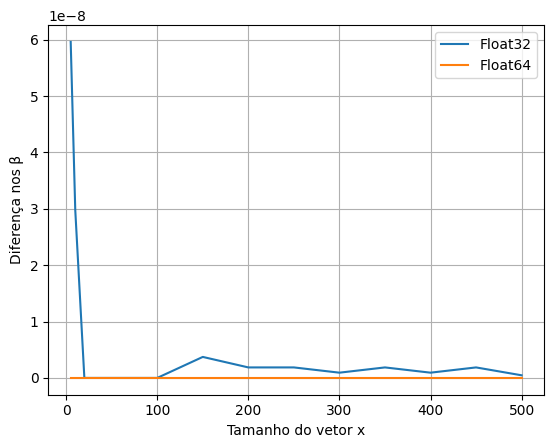

In [5]:
import matplotlib.pyplot as plt

dif_betas32 = []
dif_betas64 = []
values = [5, 10, 20, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
for value in values:
    np.random.seed(32)
    x = np.random.rand(value).astype(np.float32)
    y = np.random.rand(value).astype(np.float64)
    v1, dif_beta1 = reflector(x)
    dif_betas32.append(abs(calc_beta(v1) - dif_beta1))
    v2, dif_beta2 = reflector(y)
    dif_betas64.append(abs(calc_beta(v2) - dif_beta2))

plt.plot(values, dif_betas32, label="Float32")
plt.plot(values, dif_betas64, label="Float64")
plt.xlabel("Tamanho do vetor x")
plt.ylabel("Diferença nos \u03B2")
plt.legend()
plt.grid()
plt.show()

Como podemos ver, a diferença entre os $\beta$ calculado das duas funções é praticamente o mesmo para diversos vetores.

### 1. g)

Sabemos que $v_1 = x_1 - ||x||$. Quando $x$ está quase alinhado com $e_1$ (ou seja, $x_1 \approx ||x||$, com $y$ pequeno), temos $x_1 - ||x|| \approx 0$, uma subtração de dois números muito próximos. Isso é exatamente o mesmo problema de cancelamento numérico discutido no item b), só que agora aplicado ao cálculo de $v_1$ ao invés de $\beta$.

Para evitar esse cancelamento, multiplicamos e dividimos pelo conjugado:
$$v_1 = x_1 - ||x|| = (x_1 - ||x||)\cdot\frac{x_1 + ||x||}{x_1 + ||x||} = \frac{x_1^2 - ||x||^2}{x_1+||x||} = \frac{-||y||^2}{x_1 + ||x||}$$

Nessa nova fórmula, quando $x_1 \approx ||x||$ (caso problemático da fórmula original), o denominador $x_1 + ||x||$ é uma soma de dois números positivos próximos, então não há cancelamento. O numerador $-||y||^2$ também não envolve subtrações. Portanto:
$$v_1 = \begin{cases} x_1 - ||x|| & \text{se } x_1 < 0 \\ \dfrac{-||y||^2}{x_1+||x||} & \text{se } x_1 \geq 0\end{cases}$$

In [20]:
def v1_alt(x):
    norm_x = np.linalg.norm(x)
    y = x[1:]
    if x[0] < 0:
        return x[0] - norm_x
    return -np.linalg.norm(y)**2 / (x[0] + norm_x)

print(f"{'eps':>8}  {'v1 direto':>14}  {'v1 alternativo':>16}")
print("-"*42)
for eps in [1e-2, 1e-4, 1e-6, 1e-7, 1e-8, 1e-9]:
    x = np.array([1.0, eps])
    v1_direto = x[0] - np.linalg.norm(x)
    v1_alternativo = v1_alt(x)
    print(f"{eps:>8.0e}  {v1_direto:>14.6e}  {v1_alternativo:>16.6e}")

     eps       v1 direto    v1 alternativo
------------------------------------------
   1e-02   -4.999875e-05     -4.999875e-05
   1e-04   -5.000000e-09     -5.000000e-09
   1e-06   -5.000445e-13     -5.000000e-13
   1e-07   -4.884981e-15     -5.000000e-15
   1e-08    0.000000e+00     -5.000000e-17
   1e-09    0.000000e+00     -5.000000e-19


Como podemos ver, quando $x$ se aproxima de $e_1$ (ou seja, $\epsilon \rightarrow 0$), a fórmula direta $v_1 = x_1 - ||x||$ rapidamente perde todos os seus algarismos significativos por cancelamento, chegando a $0$ para $\epsilon = 10^{-8}$ (que está abaixo da precisão de $Float64$ nesse caso), enquanto a fórmula alternativa $v_1 = -||y||^2/(x_1+||x||)$ continua representando o valor corretamente, confirmando que ela é numericamente mais estável quando $x_1 \geq 0$.

# Questão 2

### 2. a)

Pela definição, $Q_v = I - \beta vv^*$, logo:
$$Q_v b = b - \beta v v^* b = b - \beta v (v^*b)$$
Como $v^* b$ é um escalar (produto interno), o cálculo de $Q_v b$ não precisa formar a matriz $Q_v$ explicitamente: basta calcular o produto interno $v^*b$ (custo $O(n)$) e depois subtrair $\beta(v^*b)v$ de $b$ (custo $O(n)$). Logo, $Q_v b$ tem complexidade $O(n)$, ao invés de $O(n^2)$ se formássemos $Q_v$ explicitamente.

In [7]:
def apply_reflector(v, beta, b):
    return b - beta * v * (v @ b)

### 2. b)

In [ ]:
x = np.array([3.0, 4.0])
v, beta = reflector(x)
print("Qv x =", apply_reflector(v, beta, x))
print("||x|| e1 =", np.array([np.linalg.norm(x), 0]))

np.random.seed(0)
b = np.random.rand(2)
Qb = apply_reflector(v, beta, b)
print("\n||b|| =", np.linalg.norm(b), " ||Qv b|| =", np.linalg.norm(Qb))

Qv x = [5. 0.]
||x|| e1 = [5. 0.]

||b|| = 0.9014943659641864  ||Qv b|| = 0.9014943659641864


No primeiro teste, $Q_vx$ resulta em $||x||e_1$, exatamente como esperado pela definição do refletor. No segundo teste, $Q_v$ preserva a norma de um vetor aleatório $b$, confirmando que $Q_v$ é ortogonal.

Para vetores $b$ de dimensão maior do que $v$ (digamos $b\in\mathbb{R}^m$ com $m>n=\dim(v)$), o refletor $Q_v\in\mathbb{R}^{n\times n}$ deve agir apenas nas últimas $n$ componentes de $b$, deixando as primeiras $m-n$ componentes inalteradas. Isso corresponde a embutir $Q_v$ no canto inferior direito de uma matriz identidade $m\times m$:
$$\tilde{Q_v} = \begin{bmatrix} I_{m-n} & 0 \\ 0 & Q_v\end{bmatrix}$$
Para manter a complexidade $O(n)$ (e não $O(m)$), aplicamos $Q_v$ apenas no subvetor $b[m-n:]$ e mantemos $b[:m-n]$ intacto.

In [ ]:
def apply_reflector_general(v, beta, b):
    n = len(v)
    b = b.copy()
    b[-n:] = apply_reflector(v, beta, b[-n:])
    return b

b_grande = np.random.rand(5)
b_novo = apply_reflector_general(v, beta, b_grande)
print("b original:", b_grande)
print("b após refletor (últimas 2 entradas alteradas):", b_novo)
print("\n||b|| =", np.linalg.norm(b_grande), " ||Qv b|| =", np.linalg.norm(b_novo))

b original: [0.60276338 0.54488318 0.4236548  0.64589411 0.43758721]
b após refletor (últimas 2 entradas alteradas): [0.60276338 0.54488318 0.4236548  0.73760624 0.25416296]

||b|| = 1.2034810062497148  ||Qv b|| = 1.2034810062497148


A norma do vetor inteiro é preservada, como esperado, já que $\tilde{Q_v}$ continua sendo ortogonal (é a identidade em blocos com uma submatriz ortogonal). Apenas as duas últimas componentes de $b$ foram alteradas, exatamente as que correspondem à dimensão de $v$.

### 2. c)

Para generalizar para uma matriz $A$, basta aplicar $Q_v$ (na convenção do item anterior, agindo apenas nas últimas $n=\dim(v)$ linhas) em cada coluna de $A$ separadamente. Isso pode ser feito de forma vetorizada: se $A_{sub}$ são as últimas $n$ linhas de $A$, então
$$Q_vA_{sub} = A_{sub} - \beta v(v^*A_{sub})$$
onde $v^*A_{sub}\in\mathbb{R}^{1\times p}$ é calculado em $O(np)$ e o produto externo $v(v^*A_{sub})$ também custa $O(np)$, mantendo a complexidade total $O(np)$ (ao invés de $O(n^2p)$ formando $Q_v$ explicitamente).

In [ ]:
def apply_reflector(v, beta, A):
    n = len(v)
    A = A.copy()
    A[-n:, :] = A[-n:, :] - beta * np.outer(v, v @ A[-n:, :])
    return A

np.random.seed(1)
A = np.random.rand(4, 4)
x = A[1:, 0]
v, beta = reflector(x)
QA = apply_reflector(v, beta, A)
print("Coluna 0 de QvA (entradas 1:4 devem ser [||x||, 0, 0]):")
print(QA[1:, 0])

Coluna 0 de QvA (entradas 1:4 devem ser [||x||, 0, 0]):
[0.46985364 0.         0.        ]


### 2. d)

De forma análoga, $AQ_v = A(I-\beta vv^*) = A - \beta(Av)v^*$. Se $A_{sub}$ são as últimas $n$ colunas de $A$, então
$$A_{sub}Q_v = A_{sub} - \beta(A_{sub}v)v^*$$
onde $A_{sub}v\in\mathbb{R}^{p}$ custa $O(np)$ e o produto externo $(A_{sub}v)v^*$ também custa $O(np)$, mantendo complexidade $O(np)$.

In [ ]:
def rev_apply_reflector(v, beta, A):
    n = len(v)
    A = A.copy()
    A[:, -n:] = A[:, -n:] - beta * np.outer(A[:, -n:] @ v, v)
    return A

AQ = rev_apply_reflector(v, beta, A)
print("Normas das linhas de A:   ", np.linalg.norm(A, axis=1))
print("Normas das linhas de AQv: ", np.linalg.norm(AQ, axis=1))

Normas das linhas de A:    [0.88553923 0.42914891 1.04546531 1.12390734]
Normas das linhas de AQv:  [0.88553923 0.42914891 1.04546531 1.12390734]


### 2. e)

Para reduzir $A$ à forma de Hessenberg, eliminamos iterativamente as entradas abaixo da subdiagonal, coluna por coluna. Para cada $k=0,\dots,m-3$, construímos um refletor $Q_k$ a partir da subcoluna $A[k+1:,k]$ que zera todas as entradas abaixo da posição $k+1$. Aplicamos $Q_k$ pela esquerda (agindo nas linhas $k+1:$) e, para manter a semelhança ($H=Q^*AQ$), aplicamos também $Q_k$ pela direita (agindo nas colunas $k+1:$), já que $Q_k^*=Q_k$ para refletores de Householder reais. A matriz $Q$ acumulada é o produto $Q=Q_0Q_1\cdots Q_{m-3}$, construído aplicando cada $Q_k$ pela direita nas últimas colunas de uma matriz inicialmente igual à identidade.

Note que, ao zerarmos a coluna $k$ pela esquerda com $Q_k$, a aplicação de $Q_k$ pela direita não estraga os zeros já criados nas colunas $0,\dots,k-1$, pois $Q_k$ só afeta as colunas $k+1:$.

In [ ]:
def to_hessemberg(A, return_Q=True):
    m = A.shape[0]
    H = A.copy().astype(float)
    reflectors = []
    Q = np.eye(m) if return_Q else None

    for k in range(m - 2):
        x = H[k+1:, k]
        if np.allclose(x, 0):
            v, beta = np.zeros_like(x), 0.0
        else:
            v, beta = reflector(x)
        reflectors.append((v, beta))

        H[k+1:, :] = apply_reflector(v, beta, H[k+1:, :])
        H[:, k+1:] = rev_apply_reflector(v, beta, H[:, k+1:])

        if return_Q:
            Q[:, k+1:] = rev_apply_reflector(v, beta, Q[:, k+1:])

    return reflectors, H, Q

### 2. f)

In [13]:
np.random.seed(42)
print(f"{'n':>4}  {'tipo':>13}  {'||A-QHQ*||':>14}  {'||Q*Q-I||':>12}")
print("-"*48)
for n in [2, 10, 100]:
    A = np.random.rand(n, n)

    _, H, Q = to_hessemberg(A)
    err1 = np.linalg.norm(A - Q @ H @ Q.T)
    err2 = np.linalg.norm(Q.T @ Q - np.eye(n))
    print(f"{n:>4}  {'não simétrica':>13}  {err1:>14.2e}  {err2:>12.2e}")

    A_sym = A + A.T
    _, H, Q = to_hessemberg(A_sym)
    err1 = np.linalg.norm(A_sym - Q @ H @ Q.T)
    err2 = np.linalg.norm(Q.T @ Q - np.eye(n))
    print(f"{n:>4}  {'simétrica':>13}  {err1:>14.2e}  {err2:>12.2e}")

   n           tipo      ||A-QHQ*||     ||Q*Q-I||
------------------------------------------------
   2  não simétrica        0.00e+00      0.00e+00
   2      simétrica        0.00e+00      0.00e+00
  10  não simétrica        2.93e-15      1.75e-15
  10      simétrica        3.92e-15      1.50e-15
 100  não simétrica        4.96e-14      9.91e-15
 100      simétrica        7.55e-14      9.82e-15


Em todos os casos, $||A-QHQ^*||$ e $||Q^*Q-I||$ ficam na ordem de $10^{-14}$ a $10^{-15}$, ou seja, são essencialmente erro de arredondamento de $Float64$ ($\epsilon_{maq}\approx 2.2\times 10^{-16}$), confirmando que a função `to_hessemberg` está correta tanto para matrizes simétricas quanto não simétricas, e para diferentes tamanhos.

In [14]:
# Para matrizes simétricas, H deve ser tridiagonal (Hessenberg simétrica)
A_sym = np.random.rand(5, 5)
A_sym = A_sym + A_sym.T
_, H, _ = to_hessemberg(A_sym)
print("H para A simétrica (deve ser tridiagonal):")
print(np.round(H, 3))

H para A simétrica (deve ser tridiagonal):
[[ 1.406  1.427  0.     0.    -0.   ]
 [ 1.427  3.349  1.456 -0.     0.   ]
 [ 0.     1.456  0.603  0.564  0.   ]
 [ 0.    -0.     0.564 -0.017  0.211]
 [-0.     0.     0.     0.211 -0.222]]


Como esperado, quando $A$ é simétrica, $H=Q^*AQ$ também é simétrica e, sendo Hessenberg e simétrica ao mesmo tempo, é tridiagonal: todas as entradas fora da diagonal principal e das duas subdiagonais/superdiagonais adjacentes são (numericamente) zero.

# Questão 3


### 3. a)

Para achar os autovalores de $A(\omega)$, basta achar o polinômio característico e igualar a zero:
$$A(\omega) = \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}$$
$$p_A(\lambda) = det(A - \lambda I) = det(\begin{bmatrix} -\lambda & 1 \\ -\omega^2 & -\lambda \end{bmatrix})$$
$$p_A(\lambda) = \lambda^2 + \omega^2 = 0$$
$$\lambda = \pm i\omega$$
Logo, os autovalores de $A(\omega)$ são: $\pm i\omega$.

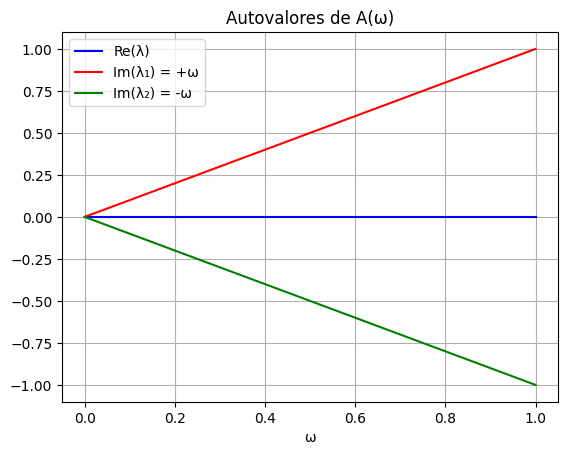

In [15]:
omegas = np.linspace(0, 1, 200)
real_parts = np.zeros_like(omegas) #parte real = 0 sempre
imag_parts = omegas #parte imaginária = +omega ou -omega

plt.plot(omegas, real_parts, label='Re(\u03bb)', color='blue')
plt.plot(omegas, imag_parts, label='Im(\u03bb\u2081) = +\u03C9', color='red')
plt.plot(omegas, -imag_parts, label='Im(\u03bb\u2082) = -\u03C9', color='green')
plt.xlabel('\u03C9')
plt.title('Autovalores de A(\u03C9)')
plt.legend()
plt.grid()
plt.show()

Como podemos perceber pelo gráfico, a parte real é zero para todo $\omega \in [0, 1]$, logo, os autovalores são puramente imaginários e podemos notar também que eles crescem linearmente com $\omega$.

Calculado os autovetores, temos: 
$$\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} \begin{bmatrix} v_1 \\ v_2 \end{bmatrix} = i\omega \begin{bmatrix} v_1 \\ v_2 \end{bmatrix}$$
O sistema fica:
$$v_2 = i\omega v_1$$
$$-\omega^2 v_1 = i\omega v_2$$
Como as duas equações são linearmente dependentes, podemos escolher $v_1 = 1$, e isso implica em $v_2 = i\omega$.

Se invertermos o sinal de $i\omega$ para $-i\omega$, o $v_2$ será $-i\omega$. Então, podemos concluir que os autovetores são: $\begin{bmatrix} 1 \\ i\omega \end{bmatrix}$ e $\begin{bmatrix} 1 \\ -i\omega \end{bmatrix}$.

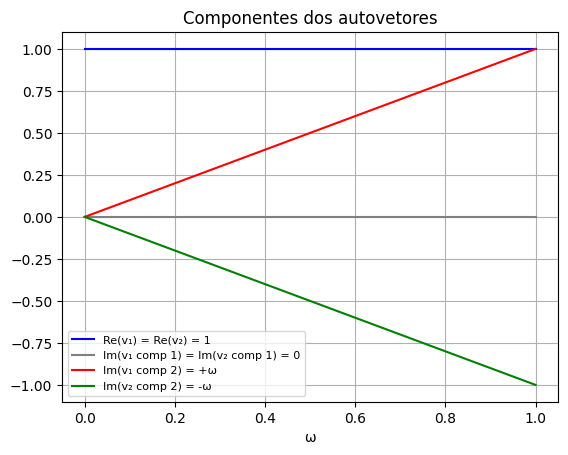

In [16]:
omegas = np.linspace(0, 1, 200)  

plt.plot(omegas, np.ones_like(omegas), color='blue', label='Re(v\u2081) = Re(v\u2082) = 1')
plt.plot(omegas, np.zeros_like(omegas), color='gray', label='Im(v\u2081 comp 1) = Im(v\u2082 comp 1) = 0')
plt.plot(omegas,  omegas, color='red',   label='Im(v\u2081 comp 2) = +\u03C9')
plt.plot(omegas, -omegas, color='green', label='Im(v\u2082 comp 2) = -\u03C9')
plt.xlabel('\u03C9')
plt.title('Componentes dos autovetores')
plt.legend(fontsize=8)
plt.grid()
plt.show()

O gráfico mostra que a segunda componente dos autovetores também varia linearmente com $\omega$, enquanto a primeira componente é puramente real e igual a $1$.

**O que acontece quando $\omega \rightarrow 0^+$?**

Quando $\omega \rightarrow 0^+$, os dois autovalores distintos viram um único autovalor $\lambda = 0$ com multiplicidade algébrica $2$ e os dois autovetores L.I se tornam um único autovetor. 

Além disso, um problema é que $A(\omega)$ é diagonalizável para $\omega > 0$, mas no limite $\omega = 0$: $$A(0) = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}$$ que é nilpotente e não diagonalizável.

### 3. b)

Para achar o condicionamento de $A$, precisamos achar seus valores singulares. Os valores singulares são as raízes dos autovalores de $A^TA$: $$A^TA = \begin{bmatrix} 0 & -\omega^2 \\ 1 & 0 \end{bmatrix}  \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} =  \begin{bmatrix} \omega^4 & 0 \\ 0 & 1 \end{bmatrix}$$

Os autovalores de $A^TA$ são $\omega^4$ e $1$, então os valores singulares são: $$\sigma _1 = 1 \hspace{3cm} \sigma _2 = \omega^2$$

O número de condicionamento de $A(\omega)$ é dado por: $$\kappa(A) = \frac{\sigma _{max}}{\sigma _{min}} = \frac{1}{\omega^2}$$ se $\omega$ for variar entre $0$ e $1$, se $\omega > 1$, então $\kappa(A) = \omega^2$. Note que nesse caso quando $\omega \rightarrow 0^+$, $\kappa(A) \rightarrow \infty$.

Para $\omega > 0$, a matriz de autovetores é: $$V = \begin{bmatrix} 1 & 1 \\ i\omega & -i\omega \end{bmatrix}$$
Calculando $V^*V$: $$V^*V = \begin{bmatrix} 1 & -i\omega \\ 1 & i\omega \end{bmatrix} \begin{bmatrix} 1 & 1 \\ i\omega & -i\omega \end{bmatrix} = \begin{bmatrix} 1 + \omega^2 & 1 - \omega^2 \\ 1 -\omega^2 & 1 + \omega^2 \end{bmatrix}$$
Os autovalores dessa matriz são $2$ e $2\omega^2$, então os valores singulares de $V$ são $\sqrt{2}$ e $\sqrt{2}\omega$, e, portanto: $$\kappa(V) = \frac{\sqrt{2}}{\sqrt{2}\omega} = \frac{1}{\omega}$$ se $\omega$ for variar entre 0 e 1, se $\omega > 1$, $\kappa(V) = \omega$.



In [17]:
omegas = np.linspace(0.01, 1, 10)
print(f"{'\u03C9':>6}  {'\u03BA(A) numérico':>15}  {'\u03BA(A) analítico':>16}  {'\u03BA(V) numérico':>15}  {'\u03BA(V) analítico':>16}")
print("-" * 75)

for omega in omegas:
    A = np.array([[0,        1],
                  [-omega**2, 0]])
    V = np.array([[1,         1        ],
                  [1j*omega, -1j*omega ]])
    
    kappa_A_num = np.linalg.cond(A)
    kappa_V_num = np.linalg.cond(V)
    kappa_A_ana = 1 / omega**2
    kappa_V_ana = 1 / omega
    
    print(f"{omega:>6.2f}  "
          f"{kappa_A_num:>15.8f}  "
          f"{kappa_A_ana:>16.8f}  "
          f"{kappa_V_num:>15.8f}  "
          f"{kappa_V_ana:>16.8f}")

     ω    κ(A) numérico    κ(A) analítico    κ(V) numérico    κ(V) analítico
---------------------------------------------------------------------------
  0.01   10000.00000000    10000.00000000     100.00000000      100.00000000
  0.12      69.44444444       69.44444444       8.33333333        8.33333333
  0.23      18.90359168       18.90359168       4.34782609        4.34782609
  0.34       8.65051903        8.65051903       2.94117647        2.94117647
  0.45       4.93827160        4.93827160       2.22222222        2.22222222
  0.56       3.18877551        3.18877551       1.78571429        1.78571429
  0.67       2.22766763        2.22766763       1.49253731        1.49253731
  0.78       1.64365549        1.64365549       1.28205128        1.28205128
  0.89       1.26246686        1.26246686       1.12359551        1.12359551
  1.00       1.00000000        1.00000000       1.00000000        1.00000000


Os valores analíticos são os que calculamos e os numéricos são os que o python calculou usando np.linalg.cond().

### 3. c) (Bônus)

Como $A(\omega)=\begin{bmatrix}0&1\\-\omega^2&0\end{bmatrix}$, calculamos:
$$A(\omega)^2 = \begin{bmatrix}0&1\\-\omega^2&0\end{bmatrix}\begin{bmatrix}0&1\\-\omega^2&0\end{bmatrix}=\begin{bmatrix}-\omega^2&0\\0&-\omega^2\end{bmatrix}=-\omega^2 I$$

Pela série de Taylor, $e^{tA}=\sum_{k=0}^{\infty}\frac{(tA)^k}{k!}$. Separando em potências pares e ímpares de $A$, e usando $A^2=-\omega^2I$ (logo $A^{2j}=(-\omega^2)^jI$ e $A^{2j+1}=(-\omega^2)^jA$):
$$e^{tA}=\sum_{j=0}^{\infty}\frac{t^{2j}A^{2j}}{(2j)!}+\sum_{j=0}^{\infty}\frac{t^{2j+1}A^{2j+1}}{(2j+1)!}=\sum_{j=0}^{\infty}\frac{(-1)^j(\omega t)^{2j}}{(2j)!}I+\sum_{j=0}^{\infty}\frac{(-1)^j(\omega t)^{2j+1}}{(2j+1)!\,\omega}A$$

Reconhecendo as séries de Taylor de $\cos$ e $\sin$:
$$e^{tA(\omega)}=\cos(\omega t)I+\frac{\sin(\omega t)}{\omega}A(\omega)$$

Quando $\omega\rightarrow0^+$, $\cos(\omega t)\rightarrow1$ e $\frac{\sin(\omega t)}{\omega}\rightarrow t$ (limite notável $\frac{\sin(x)}{x}\rightarrow1$), logo $e^{tA(\omega)}\rightarrow I+tA(0)$, que é exatamente $e^{tA(0)}$ já que $A(0)^2=0$ (nilpotente) e a série de Taylor se reduz a $I+tA(0)$.

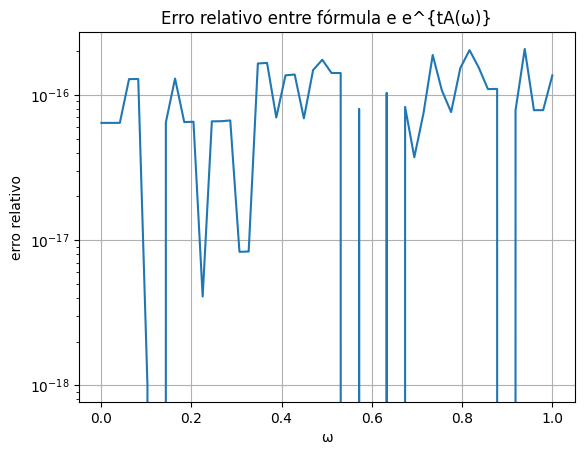

e^{tA(0)} (scipy):    [1. 1. 0. 1.]
limite da fórmula:    [1. 1. 0. 1.]


In [ ]:
from scipy.linalg import expm

t = 1.0
omegas = np.linspace(0.001, 1, 50)
errs = []
for omega in omegas:
    A = np.array([[0, 1], [-omega**2, 0]])
    exp_formula = np.cos(omega*t) * np.eye(2) + (np.sin(omega*t) / omega) * A
    exp_true = expm(t * A)
    errs.append(np.linalg.norm(exp_formula - exp_true) / np.linalg.norm(exp_true))

plt.plot(omegas, errs)
plt.xlabel('\u03C9')
plt.ylabel('erro relativo')
plt.title('Erro relativo entre f\u00f3rmula e e^{tA(\u03C9)}')
plt.yscale('log')
plt.grid()
plt.show()
 
omega = 0
A0 = np.array([[0., 1.], [0., 0.]])
exp_A0_true = expm(t * A0)
exp_A0_formula = np.eye(2) + t * A0  # limite da fórmula quando omega -> 0
print("e^{tA(0)} (scipy):   ", exp_A0_true.ravel())
print("limite da fórmula:   ", exp_A0_formula.ravel())

O erro relativo entre a fórmula $\cos(\omega t)I+\frac{\sin(\omega t)}{\omega}A(\omega)$ e o cálculo direto de $e^{tA(\omega)}$ via `scipy.linalg.expm` fica na ordem de $10^{-15}$ a $10^{-16}$ para todo $\omega\in(0,1]$, ou seja, é apenas erro de arredondamento, confirmando a fórmula. Além disso, o limite quando $\omega\rightarrow0^+$ ($I+tA(0)$) coincide exatamente com $e^{tA(0)}$ calculado diretamente, validando o caso limite.